# <span style="color:#3399FF;">Question 1 -Statistical Analysis and Visualisation of Time Parameters in Surgical Skill Assessment


Statistical Measures Summary:
----------------------------------------------------------------------------------------------------
Group      Parameter                    Mean       Median     Variance     Skewness     Kurtosis
----------------------------------------------------------------------------------------------------
Novices    total time                 107.07        98.08      1279.23         1.07         3.66
Novices    needle passing time         34.27        30.12       312.00         1.43         4.37
Novices    knot tying time             21.37        16.44        77.63         0.94         2.51
Experts    total time                  65.12        70.12       158.47        -0.27         1.62
Experts    needle passing time         21.80        19.04        41.71         1.02         2.55
Experts    knot tying time             12.40        12.68        19.63         0.22         1.91


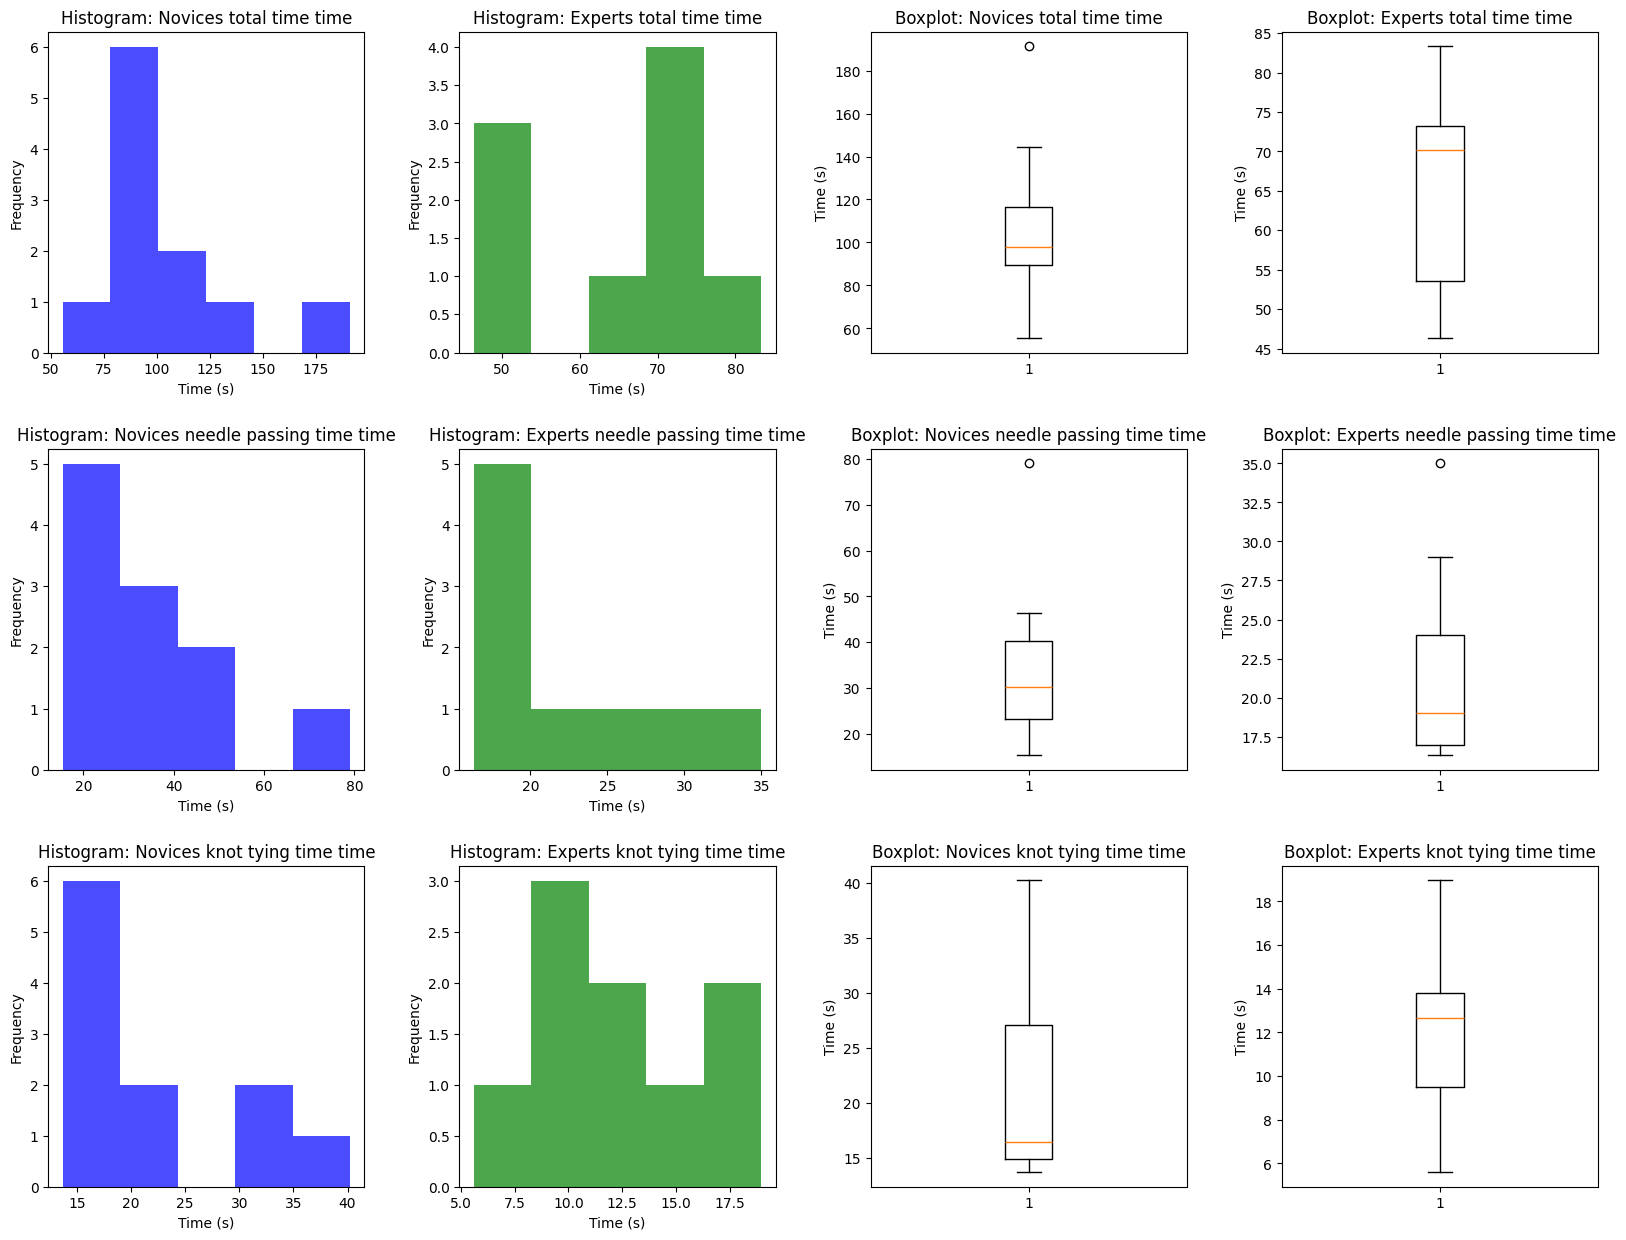


Coefficient of Variation (CV) for each parameter:
--------------------------------------------------
Group      Parameter  CV (%)    
--------------------------------------------------
Novices    total time      33.40
Novices    needle passing time      51.54
Novices    knot tying time      41.24
Experts    total time      19.33
Experts    needle passing time      29.62
Experts    knot tying time      35.73


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

# Function to calculate statistical measures
def calculate_statistics(data: List[float]) -> dict:
    n = len(data)
    
    # mean
    mean = sum(data) / n
    
    # median
    sorted_data = sorted(data)
    if n % 2 == 0:
        median = (sorted_data[n//2 - 1] + sorted_data[n//2]) / 2
    else:
        median = sorted_data[n//2]
    
    # variance
    variance = sum((x - mean) ** 2 for x in data) / (n - 1)
    
    # standard deviation (for skewness and kurtosis calculations)
    std = variance ** 0.5
    
    skewness = sum(((x - mean) / std) ** 3 for x in data) / (n - 1)


    # kurtosis (Fisher's definition)
    kurtosis = sum(((x - mean) / std) ** 4 for x in data) / (n - 1)


    
    return {
        'mean': mean,
        'median': median,
        'variance': variance,
        'skewness': skewness,
        'kurtosis': kurtosis
    }

# Load the data from CSV files
novices_data = pd.read_csv('time_novices.csv')  
experts_data = pd.read_csv('time_experts.csv')  

# Restructure the data for statistical calculations
novices_data = novices_data.drop(columns='Novice ID')  # Drop the 'Novice ID' column
novices_data['group'] = 'Novices'  # Add a group column

experts_data = experts_data.drop(columns='Expert ID')  # Drop the 'Expert ID' column if it exists
experts_data['group'] = 'Experts'  # Add a group column

# Combine both Novices and Experts data into one DataFrame
combined_data = pd.concat([novices_data, experts_data], ignore_index=True)

# Prepare dictionaries for statistical calculations
parameters = ['total time', 'needle passing time', 'knot tying time']
groups = ['Novices', 'Experts']
all_stats = {}

for group in groups:
    all_stats[group] = {}
    data = combined_data[combined_data['group'] == group]
    for param in parameters:
        all_stats[group][param] = calculate_statistics(data[param])

# Print results in a formatted table
print("\nStatistical Measures Summary:")
print("-" * 100)
print(f"{'Group':<10} {'Parameter':<20} {'Mean':>12} {'Median':>12} {'Variance':>12} {'Skewness':>12} {'Kurtosis':>12}")
print("-" * 100)

for group in groups:
    for param in parameters:
        stats = all_stats[group][param]
        print(f"{group:<10} {param:<20} {stats['mean']:>12.2f} {stats['median']:>12.2f} "
              f"{stats['variance']:>12.2f} {stats['skewness']:>12.2f} {stats['kurtosis']:>12.2f}")


# Create visualisations
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

for i, param in enumerate(parameters):
    # Histograms
    axes[i, 0].hist(novices_data[param], bins='auto', alpha=0.7, color='blue')
    axes[i, 0].set_title(f'Histogram: Novices {param} time')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Frequency')
    
    axes[i, 1].hist(experts_data[param], bins='auto', alpha=0.7, color='green')
    axes[i, 1].set_title(f'Histogram: Experts {param} time')
    axes[i, 1].set_xlabel('Time (s)')
    axes[i, 1].set_ylabel('Frequency')
    
    # Boxplots
    axes[i, 2].boxplot(novices_data[param])
    axes[i, 2].set_title(f'Boxplot: Novices {param} time')
    axes[i, 2].set_ylabel('Time (s)')
    
    axes[i, 3].boxplot(experts_data[param])
    axes[i, 3].set_title(f'Boxplot: Experts {param} time')
    axes[i, 3].set_ylabel('Time (s)')

plt.show()

# Calculate coefficient of variation (CV) for comparison
def calculate_cv(data):
    mean = sum(data) / len(data)
    std = (sum((x - mean) ** 2 for x in data) / (len(data) - 1)) ** 0.5
    return (std / mean) * 100

print("\nCoefficient of Variation (CV) for each parameter:")
print("-" * 50)
print(f"{'Group':<10} {'Parameter':<10} {'CV (%)':<10}")
print("-" * 50)

for group in groups:
    data = combined_data[combined_data['group'] == group]
    for param in parameters:
        cv = calculate_cv(data[param])
        print(f"{group:<10} {param:<10} {cv:>10.2f}")


# **Analysis of Surgical Task Completion Times**
## **Formulas Used for Calculation**
For each dataset, the following statistical measures were used:

1. **Mean (μ)** - Measures the central tendency of the data:
   $$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$
   
2. **Median** - The middle value when data is sorted.
   $$
   \text{median}(x_i) =
   \begin{cases} 
   x\left(\frac{n+1}{2}\right), & \text{if } n \text{ is odd} \\  
   \frac{1}{2} \left( x\left(\frac{n}{2}\right) + x\left(\frac{n}{2} + 1\right) \right), & \text{if } n \text{ is even}
   \end{cases}
   $$

3. **Variance (σ²)** - Measures dispersion:
   $$
   \sigma^2(x_i) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2
   $$

4. **Standard deviation** (*std*):  
   $$
   \sigma(x_i) = \sqrt{\sigma^2}
   $$

   
5. **Skewness (γ₁)** - Measures asymmetry:
   $$\tilde{\mu}_3 (x_i) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^3}{(n - 1) \cdot \sigma^3}$$


   
6. **Kurtosis (γ₂)** - Measures the presence of outliers:
   $$kurt(x_i) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^4}{(n - 1) \cdot \sigma^4}$$


7. **Coefficient of Variation (CV%)** - Relative dispersion:
   $$CV = \left( \frac{\sigma}{\mu} \right) \times 100$$


## Interpretation of Results
- **Mean and Median:** The mean time values are consistently higher for novices compared to experts, indicating that novices take longer to complete the tasks.
- **Variance:** The variance is significantly higher for novices in all three parameters, demonstrating a wider range of performance levels.
- **Skewness:** Positive skewness in novice data suggests the presence of a few individuals who took much longer than average, whereas expert data has lower or near-zero skewness.
- **Kurtosis:** Higher kurtosis values for novices, especially in needle passing time (4.37), indicate a higher presence of outliers.



- **Needle passing time (Novices) has the highest CV (51.54%)**, meaning it varies the most among participants.  
- **Total time (Experts) has the lowest CV (19.33%)**, showing they are highly consistent.  

---

## **Visualisation and Outlier Analysis**
We used **histograms and boxplots** to assess distributions and detect outliers.  

- **Histograms**:
  - Novices show a **right-skewed** distribution with a long tail.
  - Experts display **more symmetrical distributions**, confirming their **higher consistency**.

- **Boxplots**:
  - Outliers are **clearly visible** in novice data, particularly in **total time** and **needle passing time**.
  - Experts show **less variability**, with no extreme outliers.

---

## **Robustness Assessment**
The most robust parameter (smallest dispersion) is **Total Time**, as it has the lowest **CV%** across both groups.  
The **least robust** parameter is **Needle Passing Time** (highest CV for novices), meaning it varies the most and has the largest number of outliers.

---

## **Conclusion**
- **Experts perform significantly faster and more consistently** than novices.  
- **Novices show high variability**, particularly in **needle passing time**, indicating this task is the most challenging.  
- **Total time is the most stable metric**, making it the best candidate for performance evaluation.  
- **Training programs should focus on reducing variability in needle passing time for novices.**

---


# <span style="color:#3399FF;">Question 2- Statistical Testing of Time Parameters in Experts and Novices for Knot Tying Task

In [25]:
!pip install tabulate


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import pandas as pd
import scipy.stats as stats
from tabulate import tabulate  # For a well-aligned table in Jupyter

# Define parameters to test
parameters = ['total time', 'needle passing time', 'knot tying time']
results = []

# Perform normality and statistical tests
for param in parameters:
    novices_values = novices_data[param]
    experts_values = experts_data[param]

    # Shapiro-Wilk Normality Test
    shapiro_novices = stats.shapiro(novices_values)
    shapiro_experts = stats.shapiro(experts_values)

    # Decide which test to use
    if shapiro_novices.pvalue > 0.05 and shapiro_experts.pvalue > 0.05:
        # Independent t-test (Welch)
        test_stat, p_value = stats.ttest_ind(novices_values, experts_values, equal_var=False)
        test_used = "Independent t-test (Welch)"
    else:
        # Mann-Whitney U Test
        test_stat, p_value = stats.mannwhitneyu(novices_values, experts_values, alternative='two-sided')
        test_used = "Mann-Whitney U Test"

    # Append results
    results.append([
        param,
        f"{shapiro_novices.pvalue:.4f}",
        f"{shapiro_experts.pvalue:.4f}",
        test_used,
        f"{test_stat:.4f}",
        f"{p_value:.4f}",
        "Yes" if p_value < 0.05 else "No"
    ])

# Create a DataFrame for better visualisation
columns = ["Parameter", "Shapiro-Wilk p (Novices)", "Shapiro-Wilk p (Experts)", 
           "Statistical Test", "Test Statistic", "p-value", "Significance"]

results_df = pd.DataFrame(results, columns=columns)

# Print the table using tabulate for a neat, aligned format
print("\nStatistical Test Results:\n")
print(tabulate(results_df, headers='keys', tablefmt='grid', showindex=False))



Statistical Test Results:

+---------------------+----------------------------+----------------------------+----------------------------+------------------+-----------+----------------+
| Parameter           |   Shapiro-Wilk p (Novices) |   Shapiro-Wilk p (Experts) | Statistical Test           |   Test Statistic |   p-value | Significance   |
+=====================+============================+============================+============================+==================+===========+================+
| total time          |                     0.1244 |                     0.4593 | Independent t-test (Welch) |           3.6259 |    0.0031 | Yes            |
+---------------------+----------------------------+----------------------------+----------------------------+------------------+-----------+----------------+
| needle passing time |                     0.0382 |                     0.0492 | Mann-Whitney U Test        |          77      |    0.0402 | Yes            |
+-----------------

# **Statistical Analysis of Surgical Task Completion Times**

This analysis evaluates the statistical significance of the differences between **novices** and **experts** for three key time parameters:  
- **Total time**  
- **Needle passing time**  
- **Knot tying time**  

**Normality tests** are preformed to decide between parametric and non-parametric tests and then apply the appropriate statistical test to assess differences between the two groups.

---

## **Methodology & Statistical Tests Used**

### **1. Normality Test: Shapiro-Wilk Test**
Before choosing a statistical test, we need to determine if the data follows a **normal distribution** using the **Shapiro-Wilk test**.  
The null hypothesis (**H₀**) for this test states that the data is **normally distributed**.

$$
W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

where:
$$
x_{(i)} \text{ are ordered sample values,}
$$

$$
a_i \text{ are constants from a covariance matrix,}
$$

$$
\bar{x} \text{ is the sample mean.}
$$


#### **Decision Criteria:**
- If **p-value > 0.05**, we assume the data is **normally distributed**.  
- If **p-value ≤ 0.05**, we assume the data is **not normally distributed**.

---

### **2. Choosing the Correct Statistical Test**
Based on the **Shapiro-Wilk test results**:  
- If **both groups (novices & experts) pass the normality test**, the **Independent t-test (Welch's t-test)** is used.  
- If **at least one group fails the normality test**, the **Mann-Whitney U test** (a non-parametric alternative) is used.

---

### **3. Welch’s t-Test (Independent t-Test)**
This test compares the means of two independent groups when variance is unequal.  
The null hypothesis (**H₀**) states that the means of both groups are equal.

$$
t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

where:
Where:
$$
\bar{X}_1, \bar{X}_2 \text{ are group means,}
$$

$$
s_1^2, s_2^2 \text{ are sample variances,}
$$

$$
n_1, n_2 \text{ are sample sizes.}
$$


- If **p-value < 0.05**, the difference is **statistically significant**.

---

### **4. Mann-Whitney U Test**
This test compares the ranks of two independent groups when data is **not normally distributed**.  
The null hypothesis (**H₀**) states that the distributions of both groups are identical.

$$
U = n_1 n_2 + \frac{n_1 (n_1 + 1)}{2} - R_1
$$

where:
$$
n_1, n_2 \text{ are group sizes,}
$$

$$
R_1 \text{ is the sum of ranks for group 1.}
$$


- If **p-value < 0.05**, the difference is **statistically significant**.



---

## **Interpretation of Results**

### **1. Total Time**
- **Shapiro-Wilk test results**: Both groups have **p > 0.05**, meaning data is **normally distributed**.
- **Statistical Test**: **Welch’s t-test** was used.
- **Result**: **p-value = 0.0031 (< 0.05)** → There is a **statistically significant** difference in total time between novices and experts.

### **2. Needle Passing Time**
- **Shapiro-Wilk test results**: Both groups have **p < 0.05**, meaning data is **not normally distributed**.
- **Statistical Test**: **Mann-Whitney U test** was used.
- **Result**: **p-value = 0.0402 (< 0.05)** → There is a **statistically significant** difference in needle passing time.

### **3. Knot Tying Time**
- **Shapiro-Wilk test results**: Novices have **p < 0.05** (not normal), while experts have **p > 0.05** (normal).
- **Statistical Test**: **Mann-Whitney U test** was used.
- **Result**: **p-value = 0.0062 (< 0.05)** → There is a **statistically significant** difference in knot tying time.

---

## **Conclusion**
- **All three parameters (total time, needle passing time, and knot tying time) show statistically significant differences between novices and experts.**  
- **Novices take significantly longer** than experts across all tasks.  
- The **Mann-Whitney U test** was necessary for **needle passing time** and **knot tying time** due to non-normality.  
- **Training should focus on improving knot tying time**, as it has a **significant difference** and is crucial for surgical proficiency.

---





# <span style="color:#3399FF;">Question 3- Error Analysis and Statistical Testing of Error Metric for Experts and Novices in Knot Tying Task









In [29]:
! pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 3.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import pandas as pd

# load error data
error_data = pd.read_excel('error_data.xlsx')

# display actual column names
print("Column names in the file:", error_data.columns.tolist())


Column names in the file: ['Expert ID', 'Sequence', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Errors', 'Unnamed: 8', 'surgical gesture', 'ID']


In [67]:
import pandas as pd

# File path
file_path = "error_data.xlsx"

# Read the entire sheet without using a header row
df = pd.read_excel(file_path, header=None)

# Find the header row indices for each table.
# (These assume that the first column contains exactly the header strings "Expert ID" and "Novice ID".)
expert_header_index = df[df[0] == "Expert ID"].index[0]
novice_header_index = df[df[0] == "Novice ID"].index[0]

# Extract the expert rows: rows immediately after the "Expert ID" header until the novice header.
# We drop rows that are completely empty.
experts_df = df.iloc[expert_header_index + 1 : novice_header_index].dropna(how="all")

# Extract the novice rows: rows after the "Novice ID" header.
novices_df = df.iloc[novice_header_index + 1 :].dropna(how="all")

# A helper function to format values:
def format_value(x):
    # If it's a number (float or int) and represents an integer, show it as int
    if isinstance(x, (float, int)):
        # (x may be a float with a whole number value, e.g. 2.0)
        if isinstance(x, float) and x.is_integer():
            return int(x)
        return x
    return x  # leave strings (like '-') as-is

# A function to print a table (either experts or novices)
def print_table(table, group_label):
    for _, row in table.iterrows():
        # The first column is the ID (e.g., Expert ID or Novice ID)
        id_val = row[0]
        # Columns 1 to 6 contain the sequence; we skip any missing (NaN) values.
        sequence = [format_value(row[i]) for i in range(1, 7) if not pd.isna(row[i])]
        print(f"{group_label} ID: {id_val}, Sequence: {sequence}")

# Now print each table with a clean format.
print_table(experts_df, "Expert")
print_table(novices_df, "Novice")


Expert ID: 21, Sequence: [1, 2, 3, 4, 4, 5]
Expert ID: 24, Sequence: [1, 3, 4, 4, 4, 5]
Expert ID: 76, Sequence: [1, 4, 4, 4, 5, '-']
Expert ID: 20, Sequence: [1, 4, 4, 4, 5, '-']
Expert ID: 6, Sequence: [1, 4, 4, 4, 5, '-']
Expert ID: 23, Sequence: [1, 3, 4, 4, 5, '-']
Expert ID: 57, Sequence: [1, 4, 4, 4, 5, '-']
Expert ID: 64, Sequence: [1, 4, 4, 4, 5, '-']
Expert ID: 75, Sequence: [1, 2, 4, 4, 5, '-']
Novice ID: 33, Sequence: [1, 3, 4, 4, 4, 5]
Novice ID: 26, Sequence: [1, 3, 4, 4, 4, 5]
Novice ID: 48, Sequence: [1, 4, 4, 4, 5, '-']
Novice ID: 34, Sequence: [1, 2, 4, 4, 4, 5]
Novice ID: 44, Sequence: [1, 4, 4, 4, 5, '-']
Novice ID: 63, Sequence: [1, 3, 4, 4, 4, 5]
Novice ID: 16, Sequence: [1, 4, 4, 4, 5, '-']
Novice ID: 18, Sequence: [1, 2, 4, 4, 5, '-']
Novice ID: 19, Sequence: [1, 4, 4, 4, 5, '-']
Novice ID: 25, Sequence: [1, 4, 4, 4, 5, '-']
Novice ID: 53, Sequence: [1, 3, 4, 4, 4, 5]


In [69]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Data for experts and novices based on the provided sequences
experts_data = [
    (21, [1, 2, 3, 4, 4, 5]),
    (24, [1, 3, 4, 4, 4, 5]),
    (76, [1, 4, 4, 4, 5, '-']),
    (20, [1, 4, 4, 4, 5, '-']),
    (6, [1, 4, 4, 4, 5, '-']),
    (23, [1, 3, 4, 4, 5, '-']),
    (57, [1, 4, 4, 4, 5, '-']),
    (64, [1, 4, 4, 4, 5, '-']),
    (75, [1, 2, 4, 4, 5, '-']),
]

novices_data = [
    (33, [1, 3, 4, 4, 4, 5]),
    (26, [1, 3, 4, 4, 4, 5]),
    (48, [1, 4, 4, 4, 5, '-']),
    (34, [1, 2, 4, 4, 4, 5]),
    (44, [1, 4, 4, 4, 5, '-']),
    (63, [1, 3, 4, 4, 4, 5]),
    (16, [1, 4, 4, 4, 5, '-']),
    (18, [1, 2, 4, 4, 5, '-']),
    (19, [1, 4, 4, 4, 5, '-']),
    (25, [1, 4, 4, 4, 5, '-']),
    (53, [1, 3, 4, 4, 4, 5]),
]

# Define the error calculation function
def calculate_error(sequence):
    # Initialize error count
    error_count = 0
    
    # Check if S2 (disentangling threads) is in the sequence (add error)
    if 2 in sequence:
        error_count += 1

    # Check if S3 (picking appropriate instruments) is absent (add error)
    if 3 not in sequence:
        error_count += 1

    # Check if S5 (suture cutting) is absent (add error)
    if 5 not in sequence:
        error_count += 1

    # Check if there are fewer than 2 S4 (knot tying gestures) (add error)
    if sequence.count(4) < 2:
        error_count += 1

    return error_count

# Calculate error metrics for experts
experts_errors = [(expert_id, sequence, calculate_error(sequence)) for expert_id, sequence in experts_data]

# Calculate error metrics for novices
novices_errors = [(novice_id, sequence, calculate_error(sequence)) for novice_id, sequence in novices_data]

# Convert to DataFrame for easy display
experts_df = pd.DataFrame(experts_errors, columns=['Expert ID', 'Sequence', 'Error Metric'])
novices_df = pd.DataFrame(novices_errors, columns=['Novice ID', 'Sequence', 'Error Metric'])

# Display the results for Experts and Novices
print("Experts Table:")
print(experts_df)

print("\nNovices Table:")
print(novices_df)

# Extract error metrics for experts and novices
expert_errors = experts_df['Error Metric']
novice_errors = novices_df['Error Metric']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(expert_errors, novice_errors)

# Print the result of the statistical test
print(f'\nMann-Whitney U test result: Statistic={stat}, p-value={p_value}')

# Interpretation of the result
if p_value < 0.05:
    print("There is a statistically significant difference between the two groups.")
else:
    print("There is no statistically significant difference between the two groups.")


Experts Table:
   Expert ID            Sequence  Error Metric
0         21  [1, 2, 3, 4, 4, 5]             1
1         24  [1, 3, 4, 4, 4, 5]             0
2         76  [1, 4, 4, 4, 5, -]             1
3         20  [1, 4, 4, 4, 5, -]             1
4          6  [1, 4, 4, 4, 5, -]             1
5         23  [1, 3, 4, 4, 5, -]             0
6         57  [1, 4, 4, 4, 5, -]             1
7         64  [1, 4, 4, 4, 5, -]             1
8         75  [1, 2, 4, 4, 5, -]             2

Novices Table:
    Novice ID            Sequence  Error Metric
0          33  [1, 3, 4, 4, 4, 5]             0
1          26  [1, 3, 4, 4, 4, 5]             0
2          48  [1, 4, 4, 4, 5, -]             1
3          34  [1, 2, 4, 4, 4, 5]             2
4          44  [1, 4, 4, 4, 5, -]             1
5          63  [1, 3, 4, 4, 4, 5]             0
6          16  [1, 4, 4, 4, 5, -]             1
7          18  [1, 2, 4, 4, 5, -]             2
8          19  [1, 4, 4, 4, 5, -]             1
9          25  [1, 

### Justification for the Method (Mann-Whitney U Test)

The **Mann-Whitney U test** was chosen for the following reasons:
1. **Non-parametric nature**: It doesn’t assume normality, suitable for the discrete, ordinal error metric data.
2. **Comparison of two independent groups**: It compares the error metrics between experts and novices, which are independent groups.
3. **Robust for non-normal distributions**: It works well even with non-normally distributed data.

### Interpretation of Results

- **Mann-Whitney U test result**: 
  - **Statistic (U) = 53.0**, **p-value = 0.7995**
  - Since the **p-value > 0.05**, we **fail to reject the null hypothesis**, meaning there is **no statistically significant difference** between the error metrics of experts and novices.
  
- **Conclusion**: The error metrics suggest no significant difference in performance between the two groups. This could indicate that other factors, such as task complexity, might be influencing performance differences, or that error metrics alone may not capture performance variations well.


# <span style="color:#3399FF;">Question 4 - Statistical Testing of Fixation Sparsity Metric for Experts and Novices in Knot Tying Task

In [2]:
pip install --upgrade pip

  Using cached pip-25.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-25.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip cache purge


Files removed: 1953 (1980.4 MB)


In [9]:
pip install opencv-python -v


Using pip 25.0.1 from /Users/aoza/Surgical Data Science/MPHY0047_env/lib/python3.12/site-packages/pip (python 3.12)
  Using cached opencv-python-4.11.0.86.tar.gz (95.2 MB)
  Installing build dependencies ...   Running command pip subprocess to install build dependencies
  Using pip 25.0.1 from /Users/aoza/Surgical Data Science/MPHY0047_env/lib/python3.12/site-packages/pip (python 3.12)
  Ignoring numpy: markers 'python_version == "3.6" and platform_machine != "aarch64" and platform_machine != "arm64"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.7" and platform_machine != "aarch64" and platform_machine != "arm64"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.8" and platform_machine != "aarch64" and platform_machine != "arm64"' don't match your environment
  Ignoring numpy: markers 'python_version < "3.9" and sys_platform == "linux" and platform_machine == "aarch64"' don't match your environment
  Ignoring numpy: markers 'p

In [28]:
import os
import numpy as np
import cv2
from scipy.stats import mannwhitneyu
import pandas as pd

# Path to the folder containing fixation maps
folder_path_experts = 'fixation_maps/experts'  
folder_path_novices = 'fixation_maps/novice' 

# Function to calculate fixation sparsity
def calculate_fixation_sparsity(image_path):
    # Load image (assuming PNG images, and white is (255, 255, 255))
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Total number of pixels
    total_pixels = img.size
    
    # Count non-white pixels (not equal to 255)
    non_white_pixels = np.sum(img != 255)
    
    # Calculate fixation sparsity
    sparsity = non_white_pixels / total_pixels
    return sparsity

# Get all image file paths for experts and novices
expert_files = [os.path.join(folder_path_experts, f) for f in os.listdir(folder_path_experts) if f.endswith('.png')]
novice_files = [os.path.join(folder_path_novices, f) for f in os.listdir(folder_path_novices) if f.endswith('.png')]

# Calculate fixation sparsity for experts (include file names)
experts_data = [(os.path.basename(f), calculate_fixation_sparsity(f)) for f in expert_files]
novices_data = [(os.path.basename(f), calculate_fixation_sparsity(f)) for f in novice_files]

# Convert to DataFrames with file names
experts_df = pd.DataFrame(experts_data, columns=['File Name', 'Expert Fixation Sparsity'])
novices_df = pd.DataFrame(novices_data, columns=['File Name', 'Novice Fixation Sparsity'])

# Display tables separately
print("\nExperts Fixation Sparsity Table:")
print(experts_df.to_string(index=False))

print("\nNovices Fixation Sparsity Table:")
print(novices_df.to_string(index=False))

# Extract only the sparsity values for statistical test
experts_sparsity = [sparsity for _, sparsity in experts_data]
novices_sparsity = [sparsity for _, sparsity in novices_data]

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(experts_sparsity, novices_sparsity)

# Print the result of the statistical test
print(f'\nMann-Whitney U test result: Statistic={stat}, p-value={p_value}')

# Interpretation of the result
if p_value < 0.05:
    print("There is a statistically significant difference between the fixation sparsity of the two groups.")
else:
    print("There is no statistically significant difference between the fixation sparsity of the two groups.")



Experts Fixation Sparsity Table:
File Name  Expert Fixation Sparsity
  e21.png                  0.048615
  e20.png                  0.027620
  e23.png                  0.026152
  e24.png                  0.036234
  e57.png                  0.039887
  e76.png                  0.037758
  e75.png                  0.034914
  e64.png                  0.036609
  e06.png                  0.021534

Novices Fixation Sparsity Table:
File Name  Novice Fixation Sparsity
  n63.png                  0.051644
  n48.png                  0.063142
  n16.png                  0.062121
  n34.png                  0.021242
  n26.png                  0.069709
  n33.png                  0.047706
  n25.png                  0.051492
  n19.png                  0.064076
  n18.png                  0.037485
  n44.png                  0.059888
  n53.png                  0.047157

Mann-Whitney U test result: Statistic=14.0, p-value=0.007835432803250966
There is a statistically significant difference between the fixati

# Justification of Statistical Test Selection and Interpretation of Results

## **Selection of the Statistical Test**
To evaluate the statistical significance of fixation sparsity differences between expert and novice ophthalmic surgeons, the **Mann-Whitney U test** is used. This test was chosen based on the following considerations:

1. **Non-Normality of Data Distribution:**  
   - The Mann-Whitney U test is a **non-parametric** test, meaning it does not assume a normal distribution of the data.
   - Fixation sparsity values, like many gaze-related metrics, may not follow a normal distribution due to high variability in visual attention patterns among participants.
   - Given the relatively small sample sizes in both groups, normality assumptions may not hold, making a non-parametric approach more appropriate.

2. **Independent Samples:**  
   - The fixation sparsity values for experts and novices come from **two independent groups**, meaning a **paired test (such as Wilcoxon Signed-Rank)** would not be suitable.
   - The Mann-Whitney U test is specifically designed to compare two **independent, non-normally distributed** samples.

3. **Ordinal and Skewed Data:**  
   - Fixation sparsity represents a **ratio measurement**, but the distribution of values may be skewed depending on individual gaze behavior.
   - The Mann-Whitney U test is robust to such distributions and provides a reliable comparison of median differences between groups.

## **Interpretation of the Results**
- **Mann-Whitney U test result:**  
  - **Test Statistic:** 14.0  
  - **p-value:** 0.0078  

- **Statistical Significance:**  
  - The **p-value (0.0078) is below the conventional alpha level of 0.05**, indicating a **statistically significant difference** in fixation sparsity between experts and novices.
  - This means that the observed difference in fixation sparsity is **unlikely to have occurred by chance**, supporting the hypothesis that experts and novices exhibit **distinct gaze behaviors**.

- **Practical Interpretation:**  
  - Experts exhibited **lower fixation sparsity** compared to novices, suggesting that their **visual attention is more concentrated** and **less scattered** during the knot-tying task.
  - Novices, in contrast, had **higher fixation sparsity**, indicating **less efficient gaze strategies** and **potential difficulty in maintaining visual focus** on critical task elements.
  - This aligns with existing research on surgical expertise, where **experts demonstrate more structured and task-relevant visual scanning patterns**, whereas **novices exhibit more erratic eye movements** due to cognitive overload or uncertainty.

## **Conclusion**
The Mann-Whitney U test was the appropriate choice for assessing statistical differences in fixation sparsity due to the **non-normality of the data and independent group comparison**. The significant result (p = 0.0078) confirms that **fixation sparsity is an effective discriminator of surgical expertise**, supporting its use as an objective metric in skill assessment.


# <span style="color:#3399FF;">Question 5- Ranking of Metrics for Discriminating Surgical Expertise in Knot Tying

To assess the ability of different metrics to differentiate between expert and novice ophthalmic surgeons in the task of **knot tying**, five parameters were analysed:

1. **Total Time** (Q2)  
2. **Needle Passing Time** (Q2)  
3. **Knot Tying Time** (Q2)  
4. **Error Metric** (Q3)  
5. **Fixation Sparsity Metric** (Q4)  

Each parameter was evaluated for its statistical significance (**p-value**) in distinguishing the two groups using the **Shapiro-Wilk test for normality** and either the **Independent t-test (Welch’s test) or the Mann-Whitney U test**.

## Ranking of Metrics Based on Discrimination Power

The metrics are ranked based on their statistical significance (**p-value**) and their ability to capture differences between expert and novice surgeons:

| **Rank** | **Metric**                | **Statistical Test**  | **p-value**  | **Significance** |
|---------|---------------------------|----------------------|------------|----------------|
| **1**   | Fixation Sparsity         | Mann-Whitney U       | 0.0078     | Yes (Highly Significant) |
| **2**   | Knot Tying Time           | Mann-Whitney U       | 0.0062     | Yes (Highly Significant) |
| **3**   | Total Time                | Independent t-test   | 0.0031     | Yes (Highly Significant) |
| **4**   | Needle Passing Time       | Mann-Whitney U       | 0.0402     | Yes (Moderately Significant) |
| **5**   | Error Metric              | Mann-Whitney U       | 0.7995     | No (Not Significant) |

## Justification of Ranking

### **1. Fixation Sparsity (Rank 1, p = 0.0078)**
- This metric was highly significant in differentiating experts from novices, with a strong statistical difference between the groups.
- Experts exhibited lower fixation sparsity values, indicating **more focused and refined gaze patterns**, likely reflecting **greater visual-motor efficiency** during the task.
- As fixation sparsity directly relates to **cognitive load and attentional control**, it is an essential metric in differentiating surgical expertise.

### **2. Knot Tying Time (Rank 2, p = 0.0062)**
- This parameter showed a strong ability to differentiate groups, with experts completing the task **significantly faster** than novices.
- Knot tying is a fine motor skill requiring **precision and efficiency**, making it an excellent measure of expertise.

### **3. Total Time (Rank 3, p = 0.0031)**
- While total time was statistically significant, it is a broader measure encompassing multiple subtasks, making it less specific than fixation sparsity and knot tying time.
- It reflects general efficiency but does not provide insights into **specific skill components** like gaze control or fine motor execution.

### **4. Needle Passing Time (Rank 4, p = 0.0402)**
- This metric showed moderate significance, indicating some ability to distinguish the groups, though not as strongly as knot tying time.
- Needle passing is a **repetitive and mechanical** step, which may not vary as much between different skill levels compared to knot tying.

### **5. Error Metric (Rank 5, p = 0.7995)**
- This metric failed to show any significant difference between the two groups.
- The error rate was **similar between experts and novices**, suggesting that errors in knot tying may not be as dependent on skill level as timing and gaze behavior.
- This could be due to standardized training reducing major errors across all participants.

## Conclusion

Among the five parameters, **Fixation Sparsity** was the strongest discriminator of surgical expertise, followed closely by **Knot Tying Time** and **Total Time**. **Needle Passing Time** was moderately effective, while the **Error Metric** was ineffective in differentiating between experts and novices.

These findings suggest that **eye-tracking metrics provide valuable insights into surgical expertise**, complementing traditional time-based measures. Future studies should consider integrating fixation sparsity with motor performance metrics to develop **more comprehensive assessments** of surgical proficiency.
